# Clustering

The materials used in this tutorial are based on the applied exercises provided in the book "An Introduction to Statistical Learning with Applications in Python" (ISLR). We are trying to demonstrate how to implement the following unsupervised methods:
* Hierarchical clustering
* K-means

Even though you will learn how to use the above methods, it is still worth trying by yourself
* Section 12.4 in the textbook

Two of the tasks below give you code that was generated by an LLM from a plain-English request. The code runs, but it is wrong. Debugging code you did not write, and that looks confident, is now a routine part of data science work, so these tasks ask you to find the bugs, fix them, and explain how you knew. In each case the number of bugs is stated.

# 1. Hierarchical clustering
In this exercise, we are going to perform hierarchical clustering on the states of the <b><a href="https://www.statsmodels.org/dev/datasets/index.html">USArrests</a></b> data. It contains statistics on arrests in US states, i.e., the number of arrests per 100,000 residents for each of the crimes Assault, Murder and Rape, plus the percentage of the population living in urban areas (UrbanPop). The textbook shows how we can use PCA to visualise the 50 states, and reveal some interesting patterns. Here, you are going to use a hierarchical clustering algorithm to find some interesting subgroups of states in regard to the crime statistics.

In [1]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import StandardScaler
from statsmodels import datasets

In [2]:
# set seed up for the replication
np.random.seed(2)

# get help for the documentation about the function below
help(linkage)

Help on function linkage in module scipy.cluster.hierarchy:

linkage(y, method='single', metric='euclidean', optimal_ordering=False)
    Perform hierarchical/agglomerative clustering.
    
    The input y may be either a 1-D condensed distance matrix
    or a 2-D array of observation vectors.
    
    If y is a 1-D condensed distance matrix,
    then y must be a :math:`\binom{n}{2}` sized
    vector, where n is the number of original observations paired
    in the distance matrix. The behavior of this function is very
    similar to the MATLAB linkage function.
    
    A :math:`(n-1)` by 4 matrix ``Z`` is returned. At the
    :math:`i`-th iteration, clusters with indices ``Z[i, 0]`` and
    ``Z[i, 1]`` are combined to form cluster :math:`n + i`. A
    cluster with an index less than :math:`n` corresponds to one of
    the :math:`n` original observations. The distance between
    clusters ``Z[i, 0]`` and ``Z[i, 1]`` is given by ``Z[i, 2]``. The
    fourth value ``Z[i, 3]`` represents t

## 1.1 Find and fix the bugs: complete-linkage clustering of the states

An LLM was asked: *"Load the USArrests data, perform hierarchical clustering with complete linkage and Euclidean distance, draw the dendrogram with the state names as leaf labels, then cut the tree into three clusters and print the cluster of each state."*

It produced the code below. The code runs and produces a dendrogram and a list of cluster numbers, but it contains **two bugs**, both of which change the result rather than crashing. Run it as it is, then find and fix the bugs.

Hints on where to look:
* Read the docstring of `linkage` (printed above) carefully: what does it expect as its first argument, and what does it do if it receives something else?
* Read the docstring of `fcluster`: what do the arguments `t` and `criterion` mean, and how do they interact?
* Warnings are not decoration. If a cell prints one, read it.

C:\Users\quliz\AppData\Local\Temp\ipykernel_11000\3680913459.py:10: ClusterWarning: scipy.cluster: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linked = linkage(dist_matrix, method='complete')


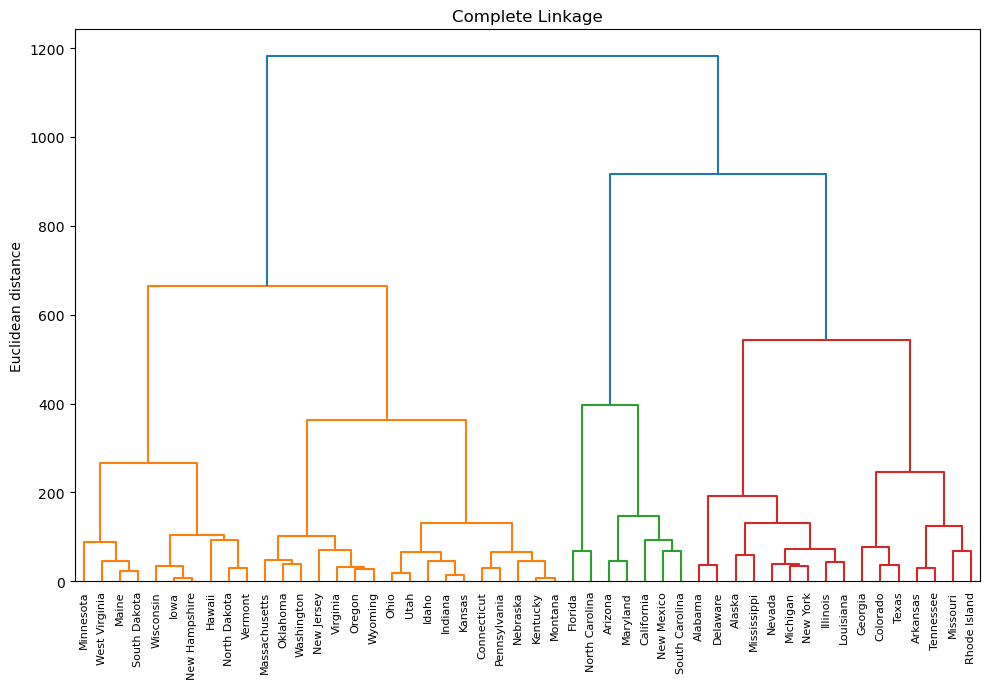

number of clusters: 50
Alabama: 35
Alaska: 37
Arizona: 30
Arkansas: 47
California: 34
Colorado: 44
Connecticut: 23
Delaware: 36
Florida: 28
Georgia: 46
Hawaii: 10
Idaho: 22
Illinois: 42
Indiana: 20
Iowa: 5
Kansas: 21
Kentucky: 25
Louisiana: 43
Maine: 1
Maryland: 31
Massachusetts: 13
Michigan: 39
Minnesota: 4
Mississippi: 38
Missouri: 49
Montana: 26
Nebraska: 27
Nevada: 41
New Hampshire: 6
New Jersey: 17
New Mexico: 32
New York: 40
North Carolina: 29
North Dakota: 8
Ohio: 18
Oklahoma: 11
Oregon: 14
Pennsylvania: 24
Rhode Island: 50
South Carolina: 33
South Dakota: 2
Tennessee: 48
Texas: 45
Utah: 19
Vermont: 9
Virginia: 16
Washington: 12
West Virginia: 3
Wisconsin: 7
Wyoming: 15


In [3]:
# ---- LLM-generated code: runs, but contains two bugs ----

# Load USArrests dataset
usarrests_data = datasets.get_rdataset("USArrests", "datasets").data

# Compute the Euclidean distance matrix between the states
dist_matrix = squareform(pdist(usarrests_data, metric='euclidean'))

# Perform hierarchical clustering using complete linkage
linked = linkage(dist_matrix, method='complete')

# Plot the dendrogram
plt.figure(figsize=(10, 7))
dendrogram(linked, labels=usarrests_data.index.tolist(), orientation='top')
plt.title("Complete Linkage")
plt.ylabel("Euclidean distance")
plt.tight_layout()
plt.show()

# Cut the tree into three clusters and print the cluster of each state
clusters = fcluster(linked, 3, criterion='distance')
print("number of clusters:", len(set(clusters)))
for state, cluster in zip(usarrests_data.index, clusters):
    print(f"{state}: {cluster}")

Write the corrected version in the cell below. Then, in a sentence or two each, state what the two bugs were and what evidence in the output of the buggy cell pointed to each.

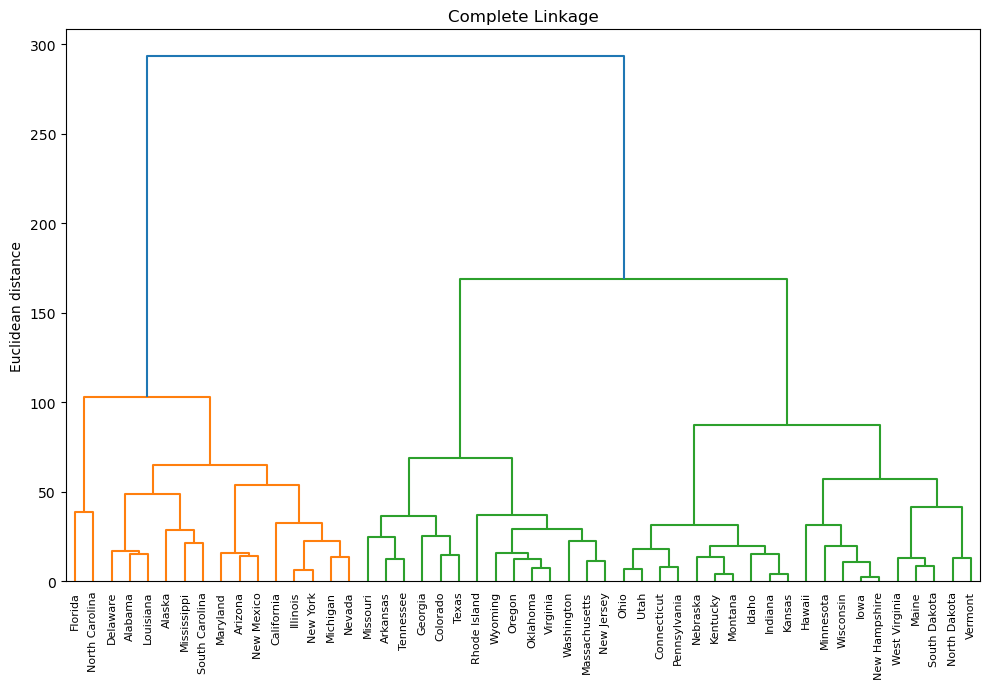

number of clusters: 3
Alabama: 1
Alaska: 1
Arizona: 1
Arkansas: 2
California: 1
Colorado: 2
Connecticut: 3
Delaware: 1
Florida: 1
Georgia: 2
Hawaii: 3
Idaho: 3
Illinois: 1
Indiana: 3
Iowa: 3
Kansas: 3
Kentucky: 3
Louisiana: 1
Maine: 3
Maryland: 1
Massachusetts: 2
Michigan: 1
Minnesota: 3
Mississippi: 1
Missouri: 2
Montana: 3
Nebraska: 3
Nevada: 1
New Hampshire: 3
New Jersey: 2
New Mexico: 1
New York: 1
North Carolina: 1
North Dakota: 3
Ohio: 3
Oklahoma: 2
Oregon: 2
Pennsylvania: 3
Rhode Island: 2
South Carolina: 1
South Dakota: 3
Tennessee: 2
Texas: 2
Utah: 3
Vermont: 3
Virginia: 2
Washington: 2
West Virginia: 3
Wisconsin: 3
Wyoming: 2


In [4]:
# ---- Corrected version ----

usarrests_data = datasets.get_rdataset("USArrests", "datasets").data

# Bug 1 fixed: linkage() expects the CONDENSED distance vector returned by pdist (or the raw observations).
# squareform() turns it into a 50 x 50 square matrix, which linkage silently treats as 50 observations
# with 50 features each, i.e. it clusters the rows of the distance matrix, not the states.
# scipy even warns about this: "... looks suspiciously like an uncondensed distance matrix".
dist_condensed = pdist(usarrests_data, metric='euclidean')
linked = linkage(dist_condensed, method='complete')

plt.figure(figsize=(10, 7))
dendrogram(linked, labels=usarrests_data.index.tolist(), orientation='top')
plt.title("Complete Linkage")
plt.ylabel("Euclidean distance")
plt.tight_layout()
plt.show()

# Bug 2 fixed: with criterion='distance', t is a HEIGHT at which to cut the tree, so t=3 cuts at
# height 3 and produced 49 clusters. To ask for three clusters, use criterion='maxclust'.
k = 3
clusters = fcluster(linked, k, criterion='maxclust')
print("number of clusters:", len(set(clusters)))
for state, cluster in zip(usarrests_data.index, clusters):
    print(f"\033[1m{state}\033[0m: {cluster}")

**What the bugs were and how to spot them.**

* **Bug 1: `squareform(pdist(...))` passed to `linkage`.** `linkage` accepts either a condensed distance vector of length $n(n-1)/2$ (what `pdist` returns) or an $n \times p$ array of observations. A square $50 \times 50$ matrix matches the second case, so it was treated as 50 observations described by 50 features and the clustering was computed on the *rows of the distance matrix*. The evidence: scipy prints a `ClusterWarning` saying the input looks like an uncondensed distance matrix, and the dendrogram heights are much larger than any distance between two states. This is a classic LLM error because both `squareform(pdist(X))` and `pdist(X)` appear in tutorials and the model does not track which one `linkage` needs.
* **Bug 2: `fcluster(linked, 3, criterion='distance')`.** With `criterion='distance'`, `t` is a height, not a number of clusters, so the tree was cut at height 3 and every state became its own cluster. The evidence is in the very first line of output: `number of clusters: 50` (with bug 1 also fixed, the same cut gives 49). The fix is `criterion='maxclust'`, for which `t` is the maximum number of clusters.

With both fixed, California, Nevada, Florida, Maryland and Alaska, the high-crime states from Figure 12.1 in the textbook, fall in the same cluster.

The plot shows a dendrogram, which looks like a tree. The leaf nodes are the data points, i.e., the 50 states. The hierarchical algorithm starts from the leaves by merging together two leaf nodes that are very similar to each other. The merging of clusters/nodes proceeds iteratively from the bottom to the top.

You can visualise the three-cluster cut directly on the dendrogram. `linked` has one row per merge, with the merge height in column 2 and the rows ordered from the first merge to the last, so a cut that produces three clusters lies between the heights of the third-last and second-last merges. `color_threshold` colours the subtrees below that height.

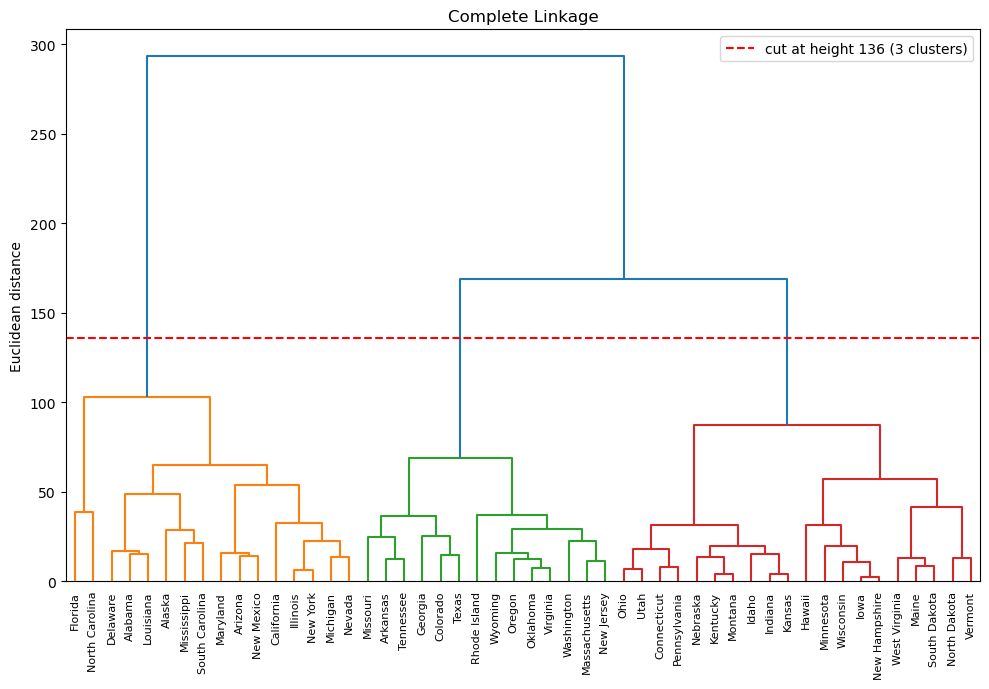

In [5]:
cut_height = (linked[-3, 2] + linked[-2, 2]) / 2      # between the 3rd-last and 2nd-last merges

plt.figure(figsize=(10, 7))
dendrogram(linked, labels=usarrests_data.index.tolist(), orientation='top', color_threshold=cut_height)
plt.axhline(cut_height, color='red', linestyle='--', label=f"cut at height {cut_height:.0f} (3 clusters)")
plt.title("Complete Linkage")
plt.ylabel("Euclidean distance")
plt.legend()
plt.tight_layout()
plt.show()

Let's look at the dendrogram together with Figure 12.1 in the textbook. The analysis under that figure says that the first principal component roughly corresponds to a measure of overall rates of serious crime. Figure 12.1 shows that states like <font color='brown'>California</font>, <font color='brown'>Nevada</font>, <font color='brown'>Florida</font>, <font color='brown'>Maryland</font>, <font color='brown'>Alaska</font> have high overall crime rates, and the dendrogram shows that they are all put into the same cluster.

## 1.2 Find and fix the bugs: scaling the variables before clustering

We have discussed how variable scale can affect both PCA and clustering. For clustering, different variable scales can have a large effect on the distances between data points: a variable measured in hundreds dominates one measured in single digits. Look at the summary below: Assault ranges over hundreds, Murder over units.

In [6]:
# Summary statistics and standard deviation of each variable
print(usarrests_data.describe())
print()
print("standard deviation of each variable:")
print(usarrests_data.std())

         Murder     Assault   UrbanPop       Rape
count  50.00000   50.000000  50.000000  50.000000
mean    7.78800  170.760000  65.540000  21.232000
std     4.35551   83.337661  14.474763   9.366385
min     0.80000   45.000000  32.000000   7.300000
25%     4.07500  109.000000  54.500000  15.075000
50%     7.25000  159.000000  66.000000  20.100000
75%    11.25000  249.000000  77.750000  26.175000
max    17.40000  337.000000  91.000000  46.000000

standard deviation of each variable:
Murder       4.355510
Assault     83.337661
UrbanPop    14.474763
Rape         9.366385
dtype: float64


The same LLM was asked: *"Standardise each variable of USArrests to have mean zero and standard deviation one, check the standard deviations afterwards, then repeat the complete-linkage clustering on the standardised data and draw the dendrogram with the state names as labels."*

Its code is below. Again it runs, and again it contains **two bugs**. One of them is caught by the check the LLM itself included; the other is visible in the plot. Find and fix both.

standard deviation after standardisation:
Murder       4.355510
Assault     83.337661
UrbanPop    14.474763
Rape         9.366385
dtype: float64


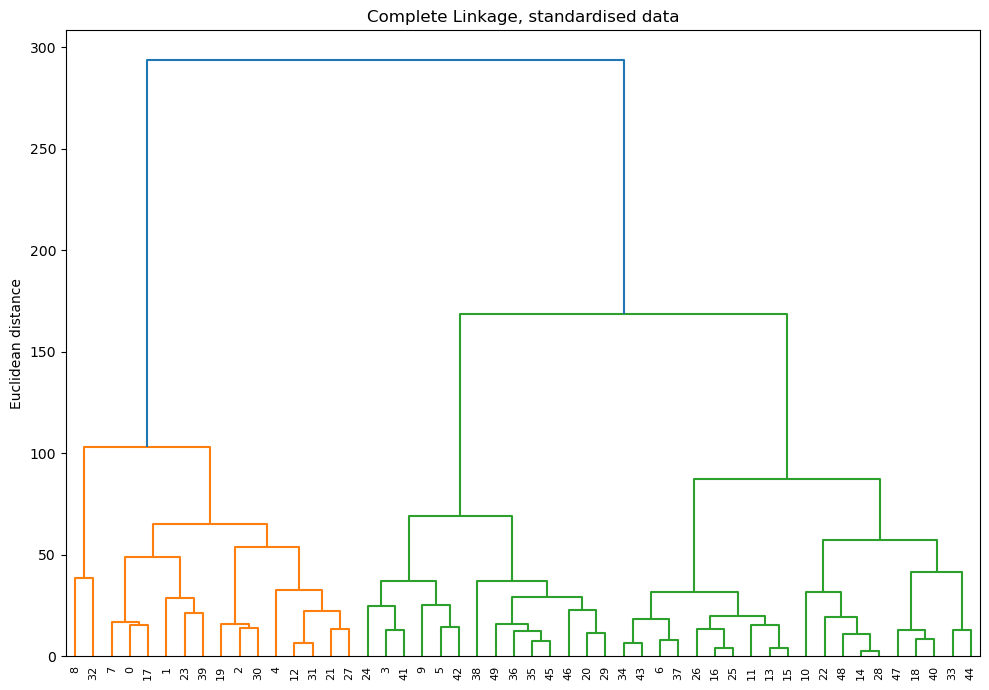

In [7]:
# ---- LLM-generated code: runs, but contains two bugs ----

# Standardise the dataset so that every variable has standard deviation one
scaler = StandardScaler(with_std=False)
sd_usarrests = scaler.fit_transform(usarrests_data)

# Convert the standardised array back to a DataFrame for easy summary
sd_usarrests_df = pd.DataFrame(sd_usarrests, columns=usarrests_data.columns)

# Check the standard deviation of each variable after standardisation
print("standard deviation after standardisation:")
print(sd_usarrests_df.std())

# Hierarchical clustering on the standardised data
linked_std = linkage(pdist(sd_usarrests_df, metric='euclidean'), method='complete')

plt.figure(figsize=(10, 7))
dendrogram(linked_std, labels=sd_usarrests_df.index.tolist(), orientation='top')
plt.title("Complete Linkage, standardised data")
plt.ylabel("Euclidean distance")
plt.tight_layout()
plt.show()

Write the corrected version below and state what the two bugs were. Then compare the corrected dendrogram with the one from 1.1: how many clusters does it suggest, and which states does the rightmost cluster contain?

standard deviation after standardisation:
Murder      1.010153
Assault     1.010153
UrbanPop    1.010153
Rape        1.010153
dtype: float64


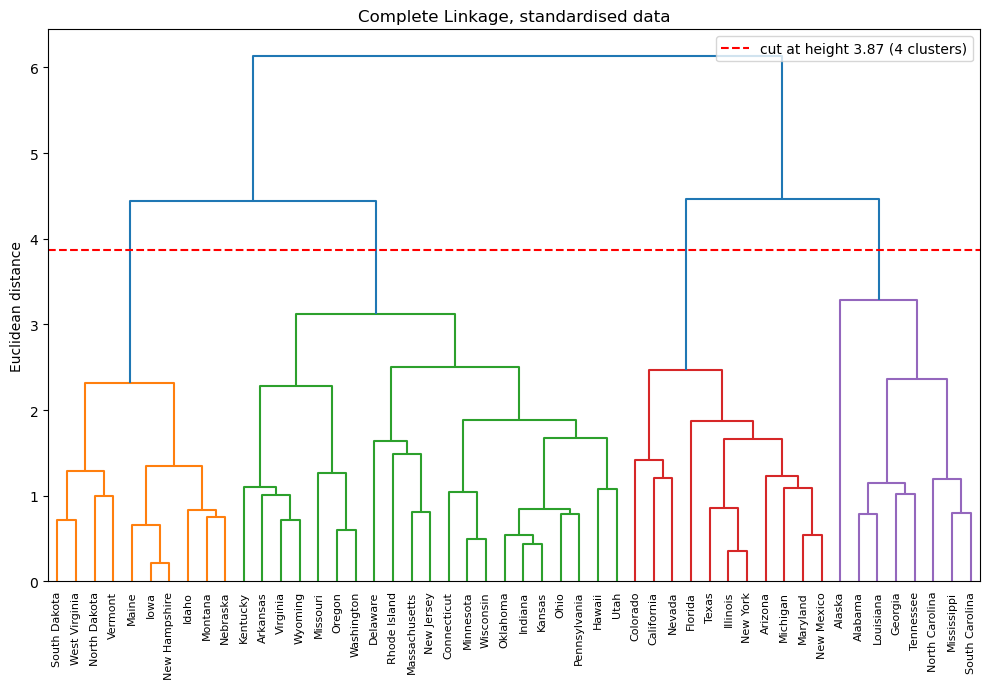

In [8]:
# ---- Corrected version ----

# Bug 1 fixed: with_std=False tells StandardScaler to centre only, so the standard deviations
# printed by the check were the ORIGINAL ones (4.3, 83.3, 14.5, 9.4), not one. The default
# StandardScaler() both centres and scales.
scaler = StandardScaler()
sd_usarrests = scaler.fit_transform(usarrests_data)

# Bug 2 fixed: fit_transform returns a NumPy array, which has no index. Building the DataFrame
# without index=... gives it the default index 0..49, so the dendrogram leaves were labelled
# with integers instead of state names. Keep the original index.
sd_usarrests_df = pd.DataFrame(sd_usarrests, columns=usarrests_data.columns, index=usarrests_data.index)

print("standard deviation after standardisation:")
print(sd_usarrests_df.std())

linked_std = linkage(pdist(sd_usarrests_df, metric='euclidean'), method='complete')

cut_height = (linked_std[-4, 2] + linked_std[-3, 2]) / 2    # four clusters, see the discussion below

plt.figure(figsize=(10, 7))
dendrogram(linked_std, labels=sd_usarrests_df.index.tolist(), orientation='top', color_threshold=cut_height)
plt.axhline(cut_height, color='red', linestyle='--', label=f"cut at height {cut_height:.2f} (4 clusters)")
plt.title("Complete Linkage, standardised data")
plt.ylabel("Euclidean distance")
plt.legend()
plt.tight_layout()
plt.show()

**What the bugs were.**

* **Bug 1: `StandardScaler(with_std=False)`.** This argument switches scaling *off*, so the transform only subtracted the means. The check the LLM wrote exposed it immediately: the printed standard deviations were 4.3, 83.3, 14.5 and 9.4, exactly the original ones, not one. An LLM produces this kind of bug by pattern-matching an argument name it has seen without tracking what it does; the lesson is that a check is only useful if you read its output.
* **Bug 2: `pd.DataFrame(sd_usarrests, columns=...)` without `index=`.** `fit_transform` returns a plain array, so the state names were lost and the new DataFrame got the integer index 0 to 49. The dendrogram then showed numbers as leaf labels, which is visible at a glance. Passing `index=usarrests_data.index` restores the names. (After the fix the printed standard deviations are 1.01 rather than exactly 1, because pandas `std()` divides by $n-1$ while `StandardScaler` divides by $n$; that is not a bug.)

**Comparison with 1.1.** After standardisation the tree structure is different and it suggests four clusters rather than three: with the third-last merge much lower than the second-last, the natural cut separates four groups. Looking at Figure 12.1 in the textbook together with this dendrogram, the states in the rightmost cluster are close to each other on the PCA plot, and the same holds for the second cluster from the right. Before standardisation the clustering was driven almost entirely by Assault, the variable with the largest scale; afterwards the four variables contribute comparably. More discussion of the effect of scaling on hierarchical clustering can be found in Section 12.4.3 of the textbook.

# 2. K-means clustering

In this exercise, you will generate simulated data, and then perform K-means clustering on the data. Firstly, generate a simulated data set with 20 observations in each of three classes (i.e., 60 observations in total), and 50 variables. There are a number of functions in Python that you can use to generate data. One example is the <font color="blue">np.random.randn</font> function. Be sure to add a mean shift to the observations in each class so that there are three distinct classes.

In [9]:
import numpy as np

# Set seed for reproducibility
np.random.seed(10)

# Given parameters
n = 20  # the number of samples per class
p = 50  # the number of variables

# Create data for class 1
X_1 = np.random.randn(n, p) + 1

# Create data for class 2
X_2 = np.random.randn(n, p) - 1

# Create data for class 3
X_3 = np.random.randn(n, p)
X_3[:, :p//2] += 1  # add 1 to the first half of columns
X_3[:, p//2:] -= 1  # subtract 1 from the second half of columns

# Combine the data for all classes
X = np.vstack((X_1, X_2, X_3))

# Create labels
labels = np.concatenate([np.repeat(1, n), np.repeat(2, n), np.repeat(3, n)])

## 2.1 Perform K-means clustering of the observations with different numbers of clusters.

Start with K = 3. How well do the clusters that you obtain compare to the true class labels? Hint: You can use the <font color="blue">pd.crosstab()</font> function to compare the true class labels to the class labels obtained by clustering. Be careful how you interpret the results: K-means clustering will arbitrarily number the clusters, so you cannot simply check whether the true class labels and clustering labels are the same.

In [10]:
from sklearn.cluster import KMeans

# Apply k-means clustering
kmeans = KMeans(n_clusters=3, n_init=50, random_state=42)
kmeans_out = kmeans.fit(X)

# Create a contingency table
kmeans_labels = kmeans_out.labels_ + 1
contingency_table = pd.crosstab(kmeans_labels, labels, rownames=['kmeans_cluster'], colnames=['true_labels'])
print(contingency_table)

C:\Users\quliz\anaconda3\lib\site-packages\joblib\externals\loky\backend\context.py:110: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\quliz\anaconda3\lib\site-packages\joblib\externals\loky\backend\context.py", line 199, in _count_physical_cores
    cpu_info = subprocess.run(
  File "C:\Users\quliz\anaconda3\lib\subprocess.py", line 505, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Users\quliz\anaconda3\lib\subprocess.py", line 951, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\quliz\anaconda3\lib\subprocess.py", line 1420, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
C:\Users\quliz\anaconda3\lib\site-packages\skl

true_labels      1   2   3
kmeans_cluster            
1                0  20   0
2                0   0  20
3               20   0   0


The table shows that the k-means clustering algorithm has successfully identified the three classes.

Now, try K-means clustering with K = 2. Describe your results.

In [11]:
# Apply k-means clustering with 2 centres
kmeans_2 = KMeans(n_clusters=2, n_init=50, random_state=42)
kmeans_out_2 = kmeans_2.fit(X)

cluster_assignments_2 = kmeans_out_2.labels_ + 1
print(pd.crosstab(cluster_assignments_2, labels, rownames=['kmeans_cluster'], colnames=['true_labels']))

C:\Users\quliz\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


true_labels      1   2   3
kmeans_cluster            
1                0  20  20
2               20   0   0


Comparing the cluster outputs, you will find points in two classes are merged into one cluster.

Then, perform K-means clustering with K = 4, and describe your results.

In [12]:
# Apply k-means clustering with 4 centres
kmeans_4 = KMeans(n_clusters=4, n_init=50, random_state=42)
kmeans_out_4 = kmeans_4.fit(X)

cluster_assignments_4 = kmeans_out_4.labels_ + 1
print(pd.crosstab(cluster_assignments_4, labels, rownames=['kmeans_cluster'], colnames=['true_labels']))

C:\Users\quliz\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


true_labels      1   2   3
kmeans_cluster            
1                0   0   9
2               20   0   0
3                0  20   0
4                0   0  11


The output clearly indicates that points in one class have been split into two clusters.

## 2.2 K-means on real images: raw pixels versus a learned representation

The simulated data above are easy: the classes are three Gaussian blobs, and $k$-means recovers them from the raw coordinates. Real data are rarely like that. In this task you apply exactly the same procedure as in 2.1, `KMeans` followed by `pd.crosstab`, to 500 CIFAR-10 photographs, twice: once on the raw pixel values, and once on a 512-dimensional embedding of each image produced by a ResNet-18 that was pre-trained on ImageNet, as in the Week 6 seminar. The network is frozen and never sees a CIFAR-10 label; it is only used to change the coordinates in which the images are described.

The code that loads the images and computes the embeddings is provided below; you do not need to change it. It downloads CIFAR-10 (about 170 MB, once; if you ran the Week 6 seminar notebook from the same folder it is already there) and the ResNet-18 weights (about 45 MB, once). Embedding 500 images takes under a minute on a CPU.

In [13]:
# ---- Provided: load 500 CIFAR-10 images and embed them with a frozen ResNet-18 ----
import torch
from torchvision.datasets import CIFAR10
from torchvision.models import resnet18, ResNet18_Weights
from sklearn.preprocessing import normalize
from PIL import Image

cifar = CIFAR10(root="./data", train=True, download=True)
class_names = np.array(cifar.classes)

rng = np.random.default_rng(0)
idx = rng.choice(len(cifar.data), size=500, replace=False)
images = [Image.fromarray(cifar.data[i]) for i in idx]
y_true = class_names[np.array(cifar.targets)[idx]]                            # class name of each image

X_pix = cifar.data[idx].reshape(500, -1).astype(np.float32) / 255.0          # (500, 3072) raw pixels

weights = ResNet18_Weights.IMAGENET1K_V1
preprocess = weights.transforms()
resnet = resnet18(weights=weights)
resnet.fc = torch.nn.Identity()                                               # keep the 512-d penultimate layer
resnet.eval()

with torch.no_grad():
    X_emb = np.vstack([resnet(torch.stack([preprocess(im) for im in images[s:s + 50]])).numpy()
                       for s in range(0, 500, 50)])
X_emb = normalize(X_emb)                                                      # (500, 512), L2-normalised

print("pixels:", X_pix.shape, "  embeddings:", X_emb.shape)

100%|███████████████████████████████████████████████████████████████████████████████| 170M/170M [00:58<00:00, 2.90MB/s]


pixels: (500, 3072)   embeddings: (500, 512)


Now run K-means with K = 10 (the number of classes) on `X_pix` and on `X_emb`, and produce a contingency table of cluster against true class name for each. Then answer:

1. Are there clusters that correspond mainly to a single class? In which representation?
2. Which pairs of classes are still mixed together in the embedding-space clusters, and does that make sense?
3. The algorithm and K are identical in the two runs. What does the difference between the two tables tell you about what $k$-means is actually measuring?

In [14]:
from sklearn.metrics import adjusted_rand_score

for name, X_rep in [("raw pixels", X_pix), ("ResNet-18 embeddings", X_emb)]:
    km = KMeans(n_clusters=10, n_init=20, random_state=42).fit(X_rep)
    print(f"\n=== k-means on {name}:  adjusted Rand index = {adjusted_rand_score(y_true, km.labels_):.3f} ===")
    print(pd.crosstab(km.labels_ + 1, y_true, rownames=['kmeans_cluster'], colnames=['true_class']))

C:\Users\quliz\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(



=== k-means on raw pixels:  adjusted Rand index = 0.038 ===
true_class      airplane  automobile  bird  cat  deer  dog  frog  horse  ship  \
kmeans_cluster                                                                  
1                     14           2     9    5     3    4     0      2     4   
2                      2           2    13    6     5    2    10      5     2   
3                      1           3     3   11    11   16    10      5     5   
4                      7           9     3    6     8    5     3      6     4   
5                      4           9    17    7    10    6    11      9     2   
6                      6          10     3    2     1    1     4      5    14   
7                      5           1     4    5     4    6     7      7     2   
8                      1           8     1    1     3    0     1      2     6   
9                      5           8     2    0     1    1     2      5     8   
10                     1           9     2    3 

C:\Users\quliz\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(



=== k-means on ResNet-18 embeddings:  adjusted Rand index = 0.356 ===
true_class      airplane  automobile  bird  cat  deer  dog  frog  horse  ship  \
kmeans_cluster                                                                  
1                      0           0     2    3     0   21     0      0     0   
2                      1           0    11    5     4    1    25      0     0   
3                     13           3     1    0     1    1     0      1    41   
4                      0           0     2   15     6   10     1     18     0   
5                      1           0     9    0    18    6     2     20     0   
6                      2           0    11    2    15    0    21      1     0   
7                      1          53     0    0     0    0     0      0     4   
8                     22           0    10    0     0    0     1      0     0   
9                      2           5     0    1     0    0     0      1     2   
10                     4           0  

**What to expect.** On raw pixels almost every row of the table spreads across most of the ten classes, and the adjusted Rand index is close to zero: $k$-means groups the photographs by overall brightness and background colour, because those account for most of the variation in 3,072 pixel values, and object identity accounts for very little. On the embeddings several clusters are dominated by a single class, and the ARI is many times higher. The classes that remain mixed are the ones that are visually similar even to a person looking at $32 \times 32$ thumbnails: cat with dog, automobile with truck, deer with horse, and airplane with ship (both on blue backgrounds).

The algorithm, K and random seed are identical in both runs, so the whole difference comes from the coordinates. $k$-means does not find "the clusters" in the data; it finds the partition that minimises Euclidean within-cluster scatter in whatever space it is given. Change the space, and you change what it finds. This is the same lesson as in 1.2, where standardising the four USArrests variables changed the tree, taken to its conclusion: a pre-trained network is a much more drastic change of coordinates than rescaling, and it can make structure that was invisible in the raw measurements dominant.

Two cautions for the discussion. First, the ARI on embeddings will still be well below 1: clustering is unsupervised, and the embedding was trained on a different dataset for a different task. Second, this does not mean embeddings always help. On data whose raw coordinates are already good (the digits images in the textbook, for instance) a pre-trained ImageNet network can make things worse. The representation has to remove variation you do not care about, and whether it does is an empirical question, which is why the contingency table, not the ARI alone, is the thing to look at.

# More reference reading materials
* <a href="https://scikit-learn.org/stable/modules/clustering.html">Cluster Analysis</a> provided on the scikit-learn website
* <a href="https://docs.scipy.org/doc/scipy/reference/cluster.hierarchy.html">scipy.cluster.hierarchy</a>: `linkage`, `dendrogram`, `fcluster`